In [1]:
# --- Core libraries ---
import warnings                       # To handle warning messages
import glob                           # For working with file paths/patterns

# --- Data manipulation ---
import pandas as pd                   # Data analysis and manipulation
import numpy as np                    # Numerical computations

# --- Visualization ---
import matplotlib.pyplot as plt       # Plotting
import matplotlib.colors as mcolors   # Advanced color handling for matplotlib
import seaborn as sns                 # Statistical plotting (built on matplotlib)
import folium                         # Interactive maps
import branca.colormap as cm          # Colormaps for Folium visualizations

# --- Machine learning / forecasting ---
from prophet import Prophet           # Time series forecasting
from sklearn.metrics import mean_absolute_error  # Model evaluation metric

# --- Pandas extensions ---
from pandas.api.types import CategoricalDtype    # Handling categorical dtypes

# --- Global settings ---
warnings.filterwarnings("ignore")     # Suppress warnings
plt.style.use('ggplot')               # Set plot style
plt.style.use('fivethirtyeight')      # Override with another style

C:\Users\Stark Solutions\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# Path to the folder containing wildfire CSV files on Google Drive
csv_path = "./"

# Find all CSV files in the specified folder and store their file paths in a list
csv_files = glob.glob(csv_path + "pre_modis_*_India.csv")

# Read each CSV file into a Pandas DataFrame and store all DataFrames in a list
dfs = [pd.read_csv(f) for f in csv_files]

# Concatenate all DataFrames into a single DataFrame, resetting the row index
df = pd.concat(dfs, ignore_index=True)

# Convert the 'acq_date' column to datetime format for easier date operations
df['acq_date'] = pd.to_datetime(df['acq_date'])

# Set 'acq_date' as the index of the DataFrame for time series handling
df.set_index('acq_date', inplace=True)

# Sort the DataFrame by date (index) in ascending order
df.sort_index(inplace=True)

# Save the combined, sorted DataFrame to a new CSV file in the same folder
df.to_csv(csv_path + "df_pre_2018_2024.csv")

# Load the dataset (CSV file) into a pandas DataFrame
# In this case, we are reading "df_2019_2024.csv" from the specified folder
df = pd.read_csv(csv_path + "df_pre_2018_2024.csv")

# Convert the 'acq_date' column to datetime objects and set it as the index
df['acq_date'] = pd.to_datetime(df['acq_date'])
df.set_index('acq_date', inplace=True)

df.head()

,latitude,longitude,brightness,scan,track,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
acq_date,,,,,,,,,,,,,,
2019-01-01,26.6812,91.0202,320.7,1.4,1.2,459,Terra,MODIS,80,6.03,297.8,25.8,D,0
2019-01-01,25.3739,91.3356,304.9,1.6,1.2,500,Terra,MODIS,55,6.03,292.0,9.4,D,0
2019-01-01,23.7829,86.3935,316.4,1.0,1.0,500,Terra,MODIS,50,6.03,300.0,8.8,D,2
2019-01-01,23.7856,86.3085,311.8,1.0,1.0,500,Terra,MODIS,66,6.03,299.7,7.1,D,2
2019-01-01,23.7726,86.3957,318.1,1.0,1.0,500,Terra,MODIS,75,6.03,301.9,11.4,D,2


In [21]:
def plot_intense_fires_folium(df, year, month=None):
    """
    Generates an interactive map showing the locations of intense fires (FRP >= 100)
    for a specific year and optional month using Folium, with color scaling by intensity
    and a legend.

    Args:
        df (pd.DataFrame): The input DataFrame with a datetime index and
                           'latitude', 'longitude', and 'frp' columns.
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). Defaults to None.
    """
    if month is not None:
        df_filtered = df[(df.index.year == year) & (df.index.month == month)].copy()
        timeframe_str = f"Intense Fires for {month}/{year}"
    else:
        df_filtered = df[df.index.year == year].copy()
        timeframe_str = f"Intense Fires for {year}"

    # Filter for intense fires (FRP >= 100)
    intense_fires_df = df_filtered[df_filtered['frp'] >= 100].copy()

    if intense_fires_df.empty:
        print(f"No intense fires found for {timeframe_str}")
        return

    # Create a base map of the US
    m = folium.Map(location=[24.434349265694888, 78.98881317709542], zoom_start=4)

    # Add markers for intense fire locations
    max_frp = intense_fires_df['frp'].max()
    min_frp = intense_fires_df['frp'].min()

    # Create a colormap for FRP values
    cmap = plt.cm.get_cmap('YlOrRd') # Yellow to Red colormap
    norm = mcolors.Normalize(vmin=min_frp, vmax=max_frp)

    for index, row in intense_fires_df.iterrows():
        # Scale FRP to a reasonable range for radius (e.g., 2 to 15)
        radius = 2 + (row['frp'] - min_frp) / (max_frp - min_frp) * 13 if max_frp > min_frp else 5
        # Scale FRP to a reasonable range for opacity (e.g., 0.4 to 0.9)
        opacity = 0.4 + (row['frp'] - min_frp) / (max_frp - min_frp) * 0.5 if max_frp > min_frp else 0.7

        # Get color from colormap based on FRP value
        color = mcolors.to_hex(cmap(norm(row['frp'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"FRP: {row['frp']:.2f}"
        ).add_to(m)

    # Add a legend
    colormap = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        index=[0, 250, 500],   # evenly spaced points in the range
        vmin=0,
        vmax=500
    )

    # Add the colormap as a legend to the map
    colormap.caption = 'Fire Radiative Power (FRP)'
    colormap.add_to(m)

    # Display the map
    display(m)

In [28]:
# TODO: Change year and month
year = 2024
month = 11

plot_intense_fires_folium(df, year, month)

In [29]:
# List of column names that we don't need for our analysis
columns_to_drop = ['acq_time', 'satellite', 'instrument', 'version', 'daynight']

# Remove the specified columns from the DataFrame "df"
# inplace=True means the change is applied directly to df without creating a new DataFrame
df.drop(columns=columns_to_drop, inplace=True)

# Display the first 5 rows of the updated DataFrame to confirm the columns were removed
df.head()

,latitude,longitude,brightness,scan,track,confidence,bright_t31,frp,type
acq_date,,,,,,,,,
2019-01-01,26.6812,91.0202,320.7,1.4,1.2,80,297.8,25.8,0
2019-01-01,25.3739,91.3356,304.9,1.6,1.2,55,292.0,9.4,0
2019-01-01,23.7829,86.3935,316.4,1.0,1.0,50,300.0,8.8,2
2019-01-01,23.7856,86.3085,311.8,1.0,1.0,66,299.7,7.1,2
2019-01-01,23.7726,86.3957,318.1,1.0,1.0,75,301.9,11.4,2


In [31]:
# TODO: Adjust latitude and longitude to the region you want
min_latitude, max_latitude = 7.9792495486449155, 37.122026412151186
min_longitude, max_longitude = 65.84141541346119, 97.54047707404737

# Filter by latitude and longitude bounds
df_filtered = df[(df['latitude'] >= min_latitude) & (df['latitude'] <= max_latitude) & (df['longitude'] >= min_longitude) & (df['longitude'] <= max_longitude)]

print(f"Number of rows after filtering: {len(df_filtered)}")

Number of rows after filtering: 587879


In [32]:
# Create a map centered around the area
m = folium.Map(location=[(min_latitude + max_latitude) / 2, (min_longitude + max_longitude) / 2], zoom_start=6)

# Add a rectangle representing the boundaries
folium.Rectangle(
    bounds=[(min_latitude, min_longitude), (max_latitude, max_longitude)],
    color='#ff7800',
    weight=2,
    fill=True,
    fill_color='#ffff00',
    fill_opacity=0.2
).add_to(m)

# Display the map
display(m)

In [33]:
# Aggregate by daily, drop latitude and longitude, and median other features
df = df_filtered.resample('D').median()

# Drop NaN values
df.dropna(inplace=True)

# Display the dataset
df.head()

,latitude,longitude,brightness,scan,track,confidence,bright_t31,frp,type
acq_date,,,,,,,,,
2019-01-01,21.31885,80.43385,314.6,1.2,1.1,60.0,300.15,9.60,0.0
2019-01-02,20.96110,77.36290,313.4,1.1,1.0,61.0,299.50,10.30,0.0
2019-01-03,21.69960,82.35070,312.7,1.1,1.0,62.0,300.30,7.70,0.0
2019-01-04,19.92915,77.15375,314.0,1.2,1.1,59.0,299.45,9.65,0.0
2019-01-05,21.27130,82.35390,314.4,1.1,1.1,64.0,301.95,9.50,0.0


In [35]:
def create_features(df):
    """
    Creates time series features from datetime index and concatenates to original df.
    """
    df = df.copy()
    df['date'] = df.index
    df['month'] = df['date'].dt.month
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300],
                          labels=['Spring', 'Summer', 'Fall', 'Winter']
                   )
    df = df.drop(columns=['date', 'date_offset']) # Drop temporary columns

    return df

df_features = create_features(df)
X = df_features.drop(columns=['frp'])
y = df_features['frp']

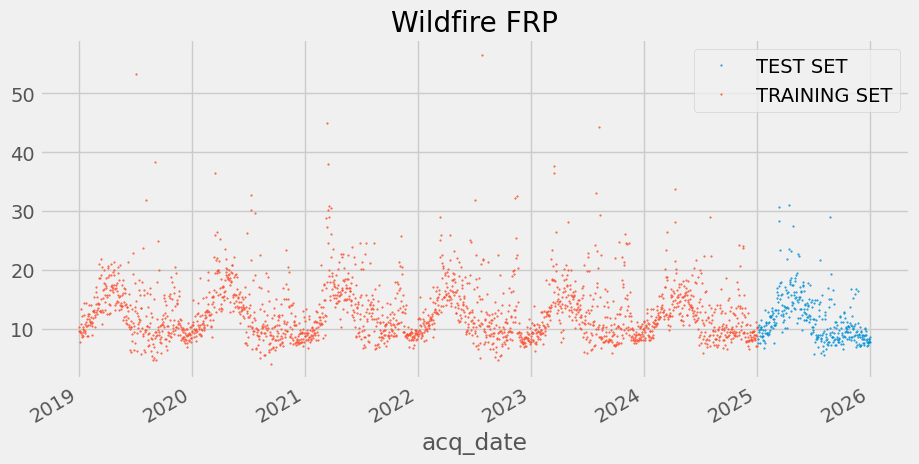

In [37]:
# TODO: Change date
split_date = '1-Jan-2025'
df_train = df_features.loc[df_features.index <= split_date].copy()
df_test = df_features.loc[df_features.index > split_date].copy()

# Plot train and test so you can see where we have split
pd.concat([df_test.groupby(df_test.index)['frp'].mean().rename('TEST SET'),
           df_train.groupby(df_train.index)['frp'].mean().rename('TRAINING SET')],
          axis=1) \
    .plot(figsize=(10, 5), title='Wildfire FRP', style='.', ms=1)
plt.show()

In [38]:
# Format data for prophet model using ds and y
df_train_prophet = df_train.reset_index() \
    .rename(columns={'acq_date':'ds',
                     'frp':'y'})

In [39]:
%%time
# Initialize and train the Prophet model
# The Prophet model is a time series forecasting model developed by Facebook
model = Prophet()
# Fit the model to the training data
# This step can take some time as the model learns the patterns in the data
model.fit(df_train_prophet)

17:11:17 - cmdstanpy - INFO - Chain [1] start processing
17:11:19 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 266 ms
Wall time: 2.7 s


In [40]:
# Predict on test set with model
df_test_prophet = df_test.reset_index() \
    .rename(columns={'acq_date':'ds',
                     'frp':'y'})

# Use the trained Prophet model to make predictions on the test data
df_test_fcst = model.predict(df_test_prophet)

In [42]:
def plot_prophet_predictions_folium(df_fcst, year, month=None):
    """
    Generates an interactive map showing the locations of Prophet model predictions
    for a specific year and optional month using Folium, with color scaling by predicted FRP.

    Args:
        df_fcst (pd.DataFrame): The input DataFrame with 'ds', 'yhat', 'latitude',
                                'longitude' columns (from Prophet forecast and original data).
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). Defaults to None.
    """
    # Ensure 'ds' is datetime and set as index for filtering
    df_fcst['ds'] = pd.to_datetime(df_fcst['ds'])
    df_fcst.set_index('ds', inplace=True)

    if month is not None:
        df_filtered = df_fcst[(df_fcst.index.year == year) & (df_fcst.index.month == month)].copy()
        timeframe_str = f"Prophet Predictions for {month}/{year}"
    else:
        df_filtered = df_fcst[df_fcst.index.year == year].copy()
        timeframe_str = f"Prophet Predictions for {year}"

    # Drop rows with NaN in latitude or longitude
    df_filtered.dropna(subset=['latitude', 'longitude'], inplace=True)

    if df_filtered.empty:
        print(f"No predictions with location data found for {timeframe_str}")
        return

    # Create a base map of the US
    m = folium.Map(location=[23.753552279472515, 78.46055484344335], zoom_start=4)

    # Add markers for predicted fire locations
    # Use 'yhat' for coloring and radius
    max_yhat = df_filtered['yhat'].max()
    min_yhat = df_filtered['yhat'].min()

    # Create a colormap for yhat values
    cmap = plt.cm.get_cmap('YlOrRd') # Yellow to Red colormap
    norm = mcolors.Normalize(vmin=min_yhat, vmax=max_yhat)

    for index, row in df_filtered.iterrows():
        # Scale yhat to a reasonable range for radius (e.g., 2 to 15)
        radius = 2 + (row['yhat'] - min_yhat) / (max_yhat - min_yhat) * 13 if max_yhat > min_yhat else 5
        # Scale yhat to a reasonable range for opacity (e.g., 0.4 to 0.9)
        opacity = 0.4 + (row['yhat'] - min_yhat) / (max_yhat - min_yhat) * 0.5 if max_yhat > min_yhat else 0.7

        # Get color from colormap based on yhat value
        color = mcolors.to_hex(cmap(norm(row['yhat'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"Predicted FRP: {row['yhat']:.2f}"
        ).add_to(m)


      # Add a legend
    colormap = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        index=[0, 250, 500],   # evenly spaced points in the range
        vmin=0,
        vmax=500
    )

    # Add the colormap as a legend to the map
    colormap.caption = 'Fire Radiative Power (FRP)'
    colormap.add_to(m)

    # Display the map
    display(m)

In [46]:
# TODO: Change year and month
year = 2025
month = 12

# Merge latitude and longitude from df_test_prophet into df_test_fcst
df_test_fcst_merged = df_test_fcst.merge(df_test_prophet[['ds', 'latitude', 'longitude']], on='ds', how='left')

plot_prophet_predictions_folium(df_test_fcst_merged, year, month)

In [47]:
# SAVE TRAINED PROPHET MODEL OFFLINE
from joblib import dump

dump(model, "prophet_wildfire_model.joblib")
print("Model saved successfully as prophet_wildfire_model.joblib!")

Model saved successfully as prophet_wildfire_model.joblib!


In [48]:
df_features.to_csv("processed_daily_fire_data.csv")
print("Processed daily dataframe saved!")

Processed daily dataframe saved!
